# 🧠 Neural Networks from Scratch with PyTorch
### *A Hands-On Worksheet: Can a Network Learn the Shape of a Galaxy?*

---

> **How to use this worksheet:**  
> Each section has **concept explanations**, **your tasks (🔧)**, and **hints (💡)** — but hints are intentionally vague. Try to figure things out yourself first. The goal is *understanding*, not copy-pasting.

---

## 🌌 The Problem: Classifying Galaxies (Kind of)

Astronomers have discovered a mysterious nebula region. Sensors return two measurements `(x₁, x₂)` for each star, and the stars belong to **two classes** — let's call them **Red Dwarfs** (class 0) and **Blue Giants** (class 1).

The problem? **The classes form a swirling, non-linear pattern** — no straight line can separate them. Can your neural network learn the hidden boundary?

---

## 📋 Your Mission (Checklist)

- [ ] **Task 1**: Load and visualize the dataset
- [ ] **Task 2**: Build your first neural network
- [ ] **Task 3**: Train it and watch the loss fall
- [ ] **Task 4**: Visualize the decision boundary
- [ ] **Task 5**: Peer inside — visualize what each layer "sees"
- [ ] **Task 6**: Experiment with activation functions
- [ ] **Task 7**: Add depth — does more layers help?
- [ ] **Task 8 (Boss Level)**: Tackle the hard dataset

---

## ⚙️ Setup: Install & Import Everything

Run this first. We'll use **PyTorch** for the network, **sklearn** for datasets, and **matplotlib** for visualization.

In [2]:
# Run this cell first!
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


---
## 🔧 Task 1: Load & Visualize the Dataset

We'll use `make_moons` — a classic 2D dataset shaped like two interleaving crescents. Why? Because:
- It's **impossible to separate with a straight line** (linear classifiers fail here)
- It's **visually intuitive** — you can see it in 2D
- It's a great test of whether your network truly learned *curved* decision boundaries

### 🧪 Your tasks:
1. Generate the moons dataset with **500 samples** and **noise=0.25**
2. Split it into train (80%) and test (20%) sets
3. **Standardize** the features (zero mean, unit variance) — *why is this important for neural networks?*
4. Convert to PyTorch tensors
5. Plot the dataset and color the two classes differently

> 💡 **Hint 1**: `make_moons` returns `(X, y)`. The `X` has shape `(n_samples, 2)`.  
> 💡 **Hint 2**: For standardization, think `StandardScaler`. Fit on train, transform both.  
> 💡 **Hint 3**: To convert numpy → torch, use `torch.FloatTensor(X)` and `torch.LongTensor(y)`

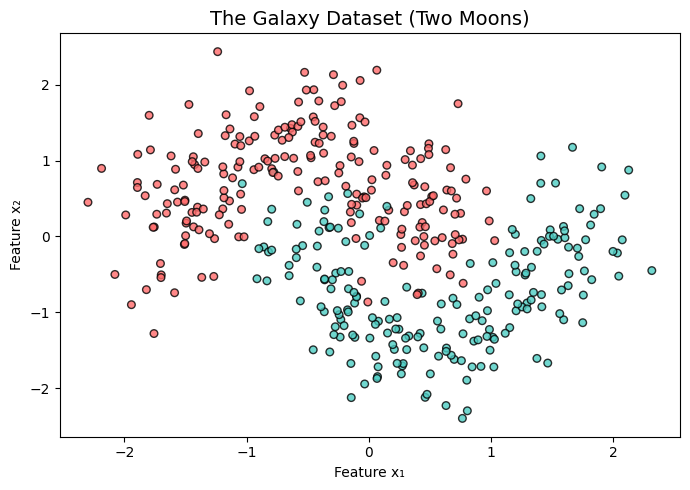

Train: (400, 2), Test: (100, 2)


In [3]:

# Step 1: Generate dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Step 4: Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# Step 5: Plot
colors = ['#FF6B6B', '#4ECDC4']
cmap   = ListedColormap(colors)
plt.figure(figsize=(7,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=cmap, edgecolors='k', s=30, alpha=0.8)
plt.title('The Galaxy Dataset (Two Moons)', fontsize=14)
plt.xlabel('Feature x₁'); plt.ylabel('Feature x₂')
plt.tight_layout(); plt.show()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

---
## 🔧 Task 2: Build Your First Neural Network

### 🧠 Concept: What is a Neural Network, Really?

A neural network is a **function approximator** made of layers:

```
Input (2 features)
    ↓
[Linear Layer]  → applies  W·x + b   (a weighted sum)
    ↓
[Activation]    → applies  f(·)       (introduces non-linearity!)
    ↓
[Linear Layer]  → ...
    ↓
Output (2 classes)
```

**Why do we need activation functions?**  
Without them, stacking 10 linear layers is *mathematically identical* to one linear layer. Try to think about why before moving on.

> 🤔 **Think**: If layer 1 is `y = W₁x + b₁` and layer 2 is `z = W₂y + b₂`, what is `z` in terms of `x`?  
> Is it still linear? What does this mean for learning curved boundaries?

### 🧪 Your task: Build a network with this structure:

| Layer | Input size | Output size | Activation |
|-------|-----------|-------------|------------|
| Linear 1 | 2 | ??? | ReLU |
| Linear 2 | ??? | ??? | ReLU |
| Linear 3 | ??? | 2 | None (raw logits) |

> 💡 **Architecture Hint**: Start small. Think about what "width" means — more neurons = more capacity but also risk of overfitting.  
> 💡 **Hint**: For the moons dataset, you don't need a huge network. A hidden layer of **8–16 neurons** is a good start.  
> 💡 **Output Hint**: We have 2 classes. The output layer should have 2 neurons (one score per class). We'll use `CrossEntropyLoss` which expects raw logits.

In [4]:
class MoonNet(nn.Module):
    def __init__(self, hidden_size=16):
        super(MoonNet, self).__init__()

        # Layer 1: Input (2 features) -> Hidden Size
        self.layer1 = nn.Linear(2, hidden_size)
        
        # Layer 2: Hidden Size -> Hidden Size
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        
        # Layer 3: Hidden Size -> Output (2 classes)
        self.output = nn.Linear(hidden_size, 2)
        
        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass through first layer + activation
        x = self.relu(self.layer1(x))
        
        # Pass through second layer + activation
        x = self.relu(self.layer2(x))
        
        # Final output (No activation here because CrossEntropyLoss handles it)
        x = self.output(x)
        
        return x

# Instantiate and inspect
model = MoonNet(hidden_size=16)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

MoonNet(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)

Total parameters: 354


---
## 🔧 Task 3: Train the Network

### 🧠 Concept: The Training Loop

Training a neural network follows a fixed ritual every epoch:

```
1. Forward pass  → compute predictions
2. Compute loss  → how wrong are we?
3. Zero gradients → clear old gradients (IMPORTANT!)
4. Backward pass → compute gradients via backprop
5. Optimizer step → update weights
```

> 🤔 **Think**: Why do we need to zero gradients each step? What happens if we don't?  
> (Hint: gradients **accumulate** in PyTorch by default.)

### 🧪 Your tasks:
1. Define the loss function: use `nn.CrossEntropyLoss()`
2. Define the optimizer: use `optim.Adam(model.parameters(), lr=0.01)`
3. Write the training loop for **1000 epochs**
4. Track and print train/test accuracy every 100 epochs
5. Plot the **loss curve** after training

> 💡 **Hint**: `CrossEntropyLoss` expects logits (raw outputs) and class indices (not one-hot).  
> 💡 **Hint**: For accuracy: `torch.argmax(outputs, dim=1)` gives predicted class.

In [5]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01):
    """
    Complete this function to train the model.
    Returns: train_losses, test_losses, train_accs, test_accs
    """
    # ===== YOUR CODE HERE =====

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accs, test_accs     = [], []

    for epoch in range(epochs):

        # --- Training mode ---
        model.train()

        # Forward pass
        train_logits = model(X_train)
        loss = criterion(train_logits, y_train)

        # 2. Backward pass (The Ritual)
        optimizer.zero_grad() # Clear old math
        loss.backward()      # Calculate how to improve (Backprop)
        optimizer.step()

        # --- Evaluation mode ---
        model.eval()
        with torch.no_grad():
            # Test forward pass
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test)
            
            # Calculate Accuracies
            # torch.argmax gives the index (0 or 1) of the highest score
            train_preds = torch.argmax(train_logits, dim=1)
            test_preds = torch.argmax(test_logits, dim=1)
            
            train_acc = (train_preds == y_train).float().mean()
            test_acc = (test_preds == y_test).float().mean()
          
        # Save metrics
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())

        # Log every 100 epochs
        if (epoch+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Test Acc: {test_accs[-1]:.2%}")

    return train_losses, test_losses, train_accs, test_accs

    # ==========================

# --- Run training ---
model = MoonNet(hidden_size=16).to(device)
losses = train_model(model, X_train_t, y_train_t, X_test_t, y_test_t, epochs=1000)

Epoch [100/1000] | Train Loss: 0.0993 | Test Acc: 94.00%
Epoch [200/1000] | Train Loss: 0.0871 | Test Acc: 93.00%
Epoch [300/1000] | Train Loss: 0.0809 | Test Acc: 93.00%
Epoch [400/1000] | Train Loss: 0.0776 | Test Acc: 92.00%
Epoch [500/1000] | Train Loss: 0.0752 | Test Acc: 91.00%
Epoch [600/1000] | Train Loss: 0.0736 | Test Acc: 91.00%
Epoch [700/1000] | Train Loss: 0.0726 | Test Acc: 91.00%
Epoch [800/1000] | Train Loss: 0.0715 | Test Acc: 92.00%
Epoch [900/1000] | Train Loss: 0.0700 | Test Acc: 92.00%
Epoch [1000/1000] | Train Loss: 0.0687 | Test Acc: 92.00%


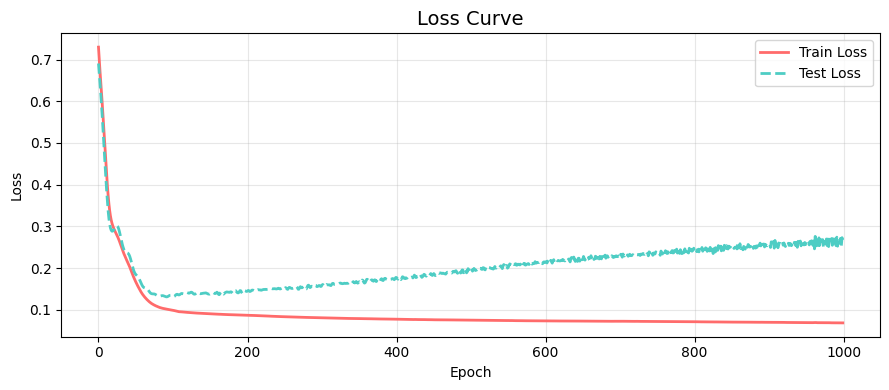

In [6]:
# Plot loss curve
def plot_loss_curve(train_losses, test_losses):
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, label='Train Loss', color='#FF6B6B', linewidth=2)
    plt.plot(test_losses,  label='Test Loss',  color='#4ECDC4', linewidth=2, linestyle='--')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss Curve', fontsize=14)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# Call after training:
train_losses, test_losses, train_accs, test_accs = losses
plot_loss_curve(train_losses, test_losses)

---
## 🔧 Task 4: Visualize the Decision Boundary

### 🧠 Concept: What is a Decision Boundary?

A decision boundary is the **line (or curve) in feature space** where the model is exactly 50% confident — it's the frontier between predicted class 0 and class 1.

To visualize it, we:
1. Create a dense **grid of points** covering the feature space
2. Run each grid point through the model
3. Color each point by its predicted class
4. Overlay the actual data points

This gives you a **heat map of the model's "mind"**.

### 🧪 Your task:
Complete the `plot_decision_boundary` function below. The grid is already set up for you — your job is to pass the grid through the model and reshape the predictions.

> 💡 **Hint**: `torch.argmax(model(grid_tensor), dim=1)` gives class predictions for each grid point.  
> 💡 **Hint**: Reshape the output to match `xx.shape` for `plt.contourf`.

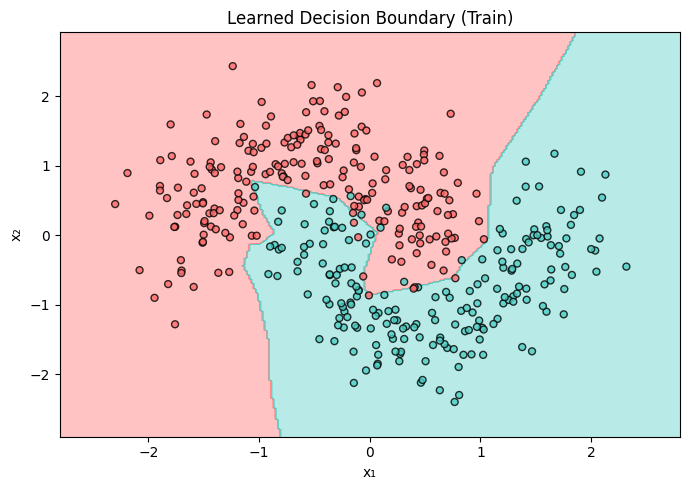

In [7]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    """
    Plots the decision boundary of the model over feature space X.
    """
    model.eval()
    colors = ['#FF6B6B', '#4ECDC4']
    cmap   = ListedColormap(colors)

    # Create grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid).to(device)

    with torch.no_grad():
        # 1. Forward pass through the model to get logits
        logits = model(grid_tensor)
        
        # 2. Get the predicted class (0 or 1) using argmax
        # dim=1 because the output is [num_points, 2_classes]
        predictions = torch.argmax(logits, dim=1)
        
        # 3. Move back to CPU and convert to numpy for plotting
        Z = predictions.cpu().numpy()
        
        # 4. Reshape Z to match the grid shape (xx)
        Z = Z.reshape(xx.shape)

    # ==========================

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, edgecolors='k', s=25, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')


# Test it!
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(model, X_train, y_train, title="Learned Decision Boundary (Train)", ax=ax)
plt.tight_layout(); plt.show()

---
## 🔧 Task 5: Peer Inside — Visualize Layer Representations

### 🧠 Concept: What Does Each Layer Learn?

Each layer in a neural network **transforms the data** into a new representation. By the final layer, the data should be **linearly separable** (the last layer can draw a straight line to separate classes).

Think of it like this:
- **Layer 1** might learn to detect basic "directions" in the data
- **Layer 2** might combine those into higher-level features
- **Output layer** just draws the final line

We can visualize these intermediate representations by:
1. Using **PyTorch hooks** to capture intermediate outputs
2. Plotting the **2D projection** of each layer's activation space

### 🧪 Your task:
The hook system is set up below. Your job is to:
1. Register hooks on `layer1` and `layer2` of your model
2. Run a forward pass on the training data
3. Plot the activations from each layer

> 💡 **Hint**: A hook is registered with `layer.register_forward_hook(fn)`. The function `fn` receives `(module, input, output)`.  
> 💡 **Tricky Part**: Since `layer1` outputs `hidden_size` dimensions (e.g. 16), we can't plot all dimensions at once. Pick any 2 dimensions (e.g. dimensions 0 and 1) to scatter plot.

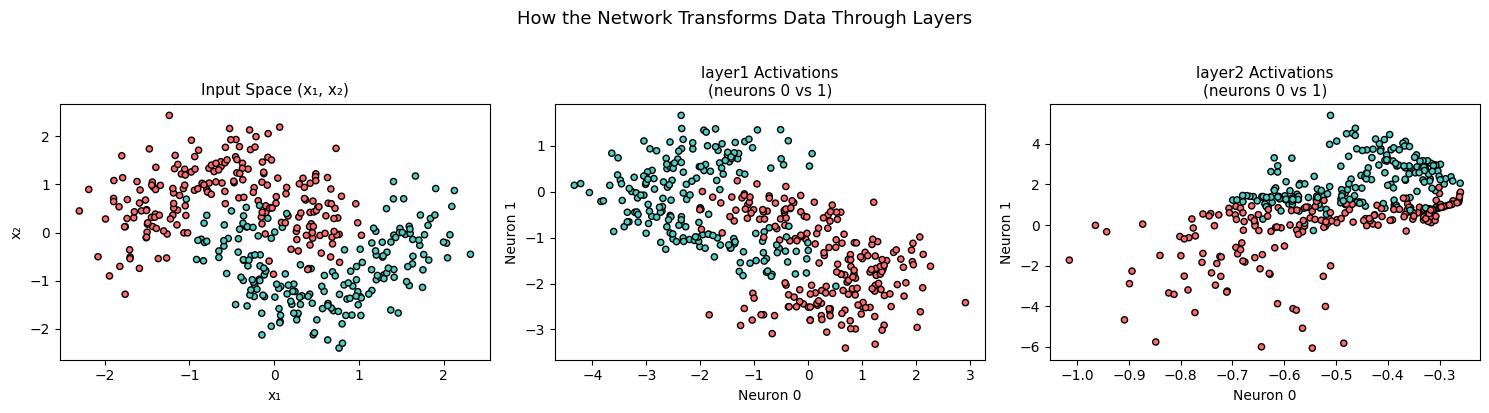


 Observe: Are the two classes more separable in deeper layers?


In [8]:
def visualize_layer_representations(model, X_tensor, y_numpy):
    """
    Captures and plots the intermediate activations from each layer.
    Shows how the data transforms as it flows through the network.
    """
    activations = {}   # dict to store captured outputs
    hooks = []

    # Helper: hook factory
    def make_hook(name):
        def hook_fn(module, input, output):
            activations[name] = output.detach().cpu().numpy()
        return hook_fn

    # Register hooks on layer1 and layer2
    h1 = model.layer1.register_forward_hook(make_hook('layer1'))
    h2 = model.layer2.register_forward_hook(make_hook('layer2'))
    hooks = [h1, h2]

    # Forward pass (no grad needed)
    model.eval()
    with torch.no_grad():
        _ = model(X_tensor)
    # ==========================

    # Remove hooks
    for h in hooks: h.remove()

    # Plotting
    colors = ['#FF6B6B', '#4ECDC4']
    cmap   = ListedColormap(colors)

    layer_names = list(activations.keys())
    fig, axes = plt.subplots(1, len(layer_names)+1, figsize=(5*(len(layer_names)+1), 4))

    # Input space
    X_np = X_tensor.cpu().numpy()
    axes[0].scatter(X_np[:,0], X_np[:,1], c=y_numpy, cmap=cmap, edgecolors='k', s=20)
    axes[0].set_title('Input Space (x₁, x₂)', fontsize=11)
    axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')

    # Layer activations
    for i, name in enumerate(layer_names):
        act = activations[name]
        # Use first two neurons to plot
        # (If only 1 neuron, duplicate axis for visualization)
        dim1 = act[:, 0] if act.shape[1] > 0 else act[:, 0]
        dim2 = act[:, 1] if act.shape[1] > 1 else act[:, 0]

        axes[i+1].scatter(dim1, dim2, c=y_numpy, cmap=cmap, edgecolors='k', s=20)
        axes[i+1].set_title(f'{name} Activations\n(neurons 0 vs 1)', fontsize=11)
        axes[i+1].set_xlabel('Neuron 0'); axes[i+1].set_ylabel('Neuron 1')

    plt.suptitle('How the Network Transforms Data Through Layers', fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    print("\n Observe: Are the two classes more separable in deeper layers?")


# Call it!
visualize_layer_representations(model, X_train_t, y_train)

---
## 🔧 Task 6: The Activation Function Showdown 🥊

### 🧠 Concept: Why Activation Functions Matter

The choice of activation function **dramatically changes** how a network learns. Let's compare:

| Activation | Formula | Key Characteristic |
|------------|---------|--------------------|
| **ReLU** | max(0, x) | Fast, can "die" for negative inputs |
| **Tanh** | (eˣ − e⁻ˣ)/(eˣ + e⁻ˣ) | Smooth, outputs in [−1, 1], can saturate |
| **Sigmoid** | 1/(1 + e⁻ˣ) | Smooth, outputs in (0, 1), vanishing gradient problem |
| **LeakyReLU** | x if x>0, αx otherwise | Fixes "dying ReLU", α is small (e.g. 0.1) |
| **ELU** | x if x>0, α(eˣ−1) otherwise | Smoother than ReLU, handles negatives |

> 🤔 **Think before running**: Which activation do you predict will:
> - Converge **fastest**?
> - Give the **smoothest** decision boundary?
> - Potentially **fail** to learn? (Can you construct an argument for why?)

### 🧪 Your task:
1. Create a version of `MoonNet` that accepts an `activation` parameter
2. Train 4 versions (ReLU, Tanh, Sigmoid, LeakyReLU) for 800 epochs each
3. Plot all 4 decision boundaries side by side
4. **Record your observations** in the markdown cell below


Training with ReLU... Epoch [100/800] | Train Loss: 0.1007 | Test Acc: 95.00%
Epoch [200/800] | Train Loss: 0.0841 | Test Acc: 93.00%
Epoch [300/800] | Train Loss: 0.0786 | Test Acc: 93.00%
Epoch [400/800] | Train Loss: 0.0743 | Test Acc: 91.00%
Epoch [500/800] | Train Loss: 0.0719 | Test Acc: 92.00%
Epoch [600/800] | Train Loss: 0.0703 | Test Acc: 92.00%
Epoch [700/800] | Train Loss: 0.0692 | Test Acc: 92.00%
Epoch [800/800] | Train Loss: 0.0683 | Test Acc: 92.00%
Done!

Training with Tanh... Epoch [100/800] | Train Loss: 0.1321 | Test Acc: 95.00%
Epoch [200/800] | Train Loss: 0.0975 | Test Acc: 95.00%
Epoch [300/800] | Train Loss: 0.0865 | Test Acc: 92.00%
Epoch [400/800] | Train Loss: 0.0796 | Test Acc: 92.00%
Epoch [500/800] | Train Loss: 0.0747 | Test Acc: 91.00%
Epoch [600/800] | Train Loss: 0.0688 | Test Acc: 91.00%
Epoch [700/800] | Train Loss: 0.0608 | Test Acc: 91.00%
Epoch [800/800] | Train Loss: 0.0514 | Test Acc: 90.00%
Done!

Training with Sigmoid... Epoch [100/800] | Tr

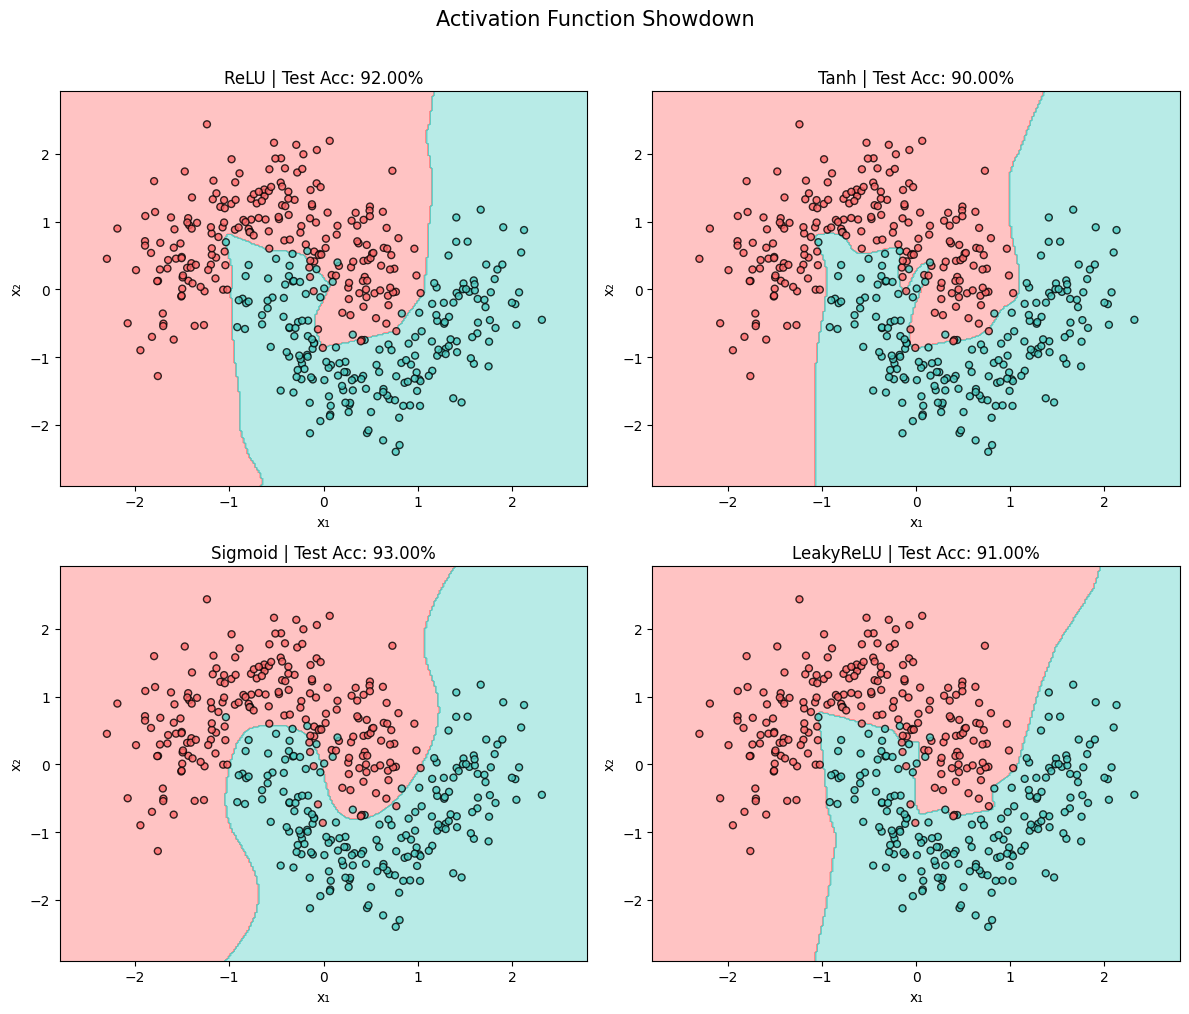

In [9]:
class FlexNet(nn.Module):
    """MoonNet that accepts any activation function."""
    def __init__(self, hidden_size=16, activation=nn.ReLU()):
        super(FlexNet, self).__init__()

        # ===== YOUR CODE HERE =====
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            activation,
            nn.Linear(hidden_size, hidden_size),
            activation,
            nn.Linear(hidden_size, 2))
    

    def forward(self, x):
        return self.net(x)
       
# Train all 4 and compare
def activation_showdown(X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train):

    activations_to_test = {
        'ReLU':       nn.ReLU(),
        'Tanh':       nn.Tanh(),
        'Sigmoid':    nn.Sigmoid(),
        'LeakyReLU':  nn.LeakyReLU(0.1),
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    results = {}

    for idx, (name, act_fn) in enumerate(activations_to_test.items()):
        print(f"\nTraining with {name}...", end=" ")

        # 1. Instantiate model with specific activation
        m = FlexNet(hidden_size=16, activation=act_fn).to(device)
        
        # 2. Train using our previous function
        # We'll use 800 epochs as requested
        tl, v_loss, t_acc, v_acc = train_model(
            m, X_train_t, y_train_t, X_test_t, y_test_t, epochs=800, lr=0.01
        )
        
        results[name] = {'model': m, 'final_test_acc': v_acc[-1]}

        # 3. Visualize the "mind" of this specific activation
        plot_decision_boundary(m, X_train, y_train, 
                               title=f"{name} | Test Acc: {v_acc[-1]:.2%}", 
                               ax=axes[idx])
        print("Done!")
        
    plt.suptitle('Activation Function Showdown', fontsize=15, y=1.01)
    plt.tight_layout(); plt.show()
    return results


results = activation_showdown(X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train)

### 📝 Record Your Observations Here:

*Edit this cell after running the showdown!*

| Activation | Final Test Accuracy | Decision Boundary Shape | Notes |
|------------|---------------------|--------------------------|-------|
| ReLU | ??? | ??? | ??? |
| Tanh | ??? | ??? | ??? |
| Sigmoid | ??? | ??? | ??? |
| LeakyReLU | ??? | ??? | ??? |

**Which was best? Why do you think?**  
*(Write your hypothesis here)*

---
## 🔧 Task 7: Go Deeper — Does Depth Help?

### 🧠 Concept: Width vs. Depth

There are two ways to make a network "bigger":
- **Width**: More neurons per layer → can represent more features simultaneously
- **Depth**: More layers → can compose more complex transformations

Theoretically, any function can be approximated by a **single wide layer** (Universal Approximation Theorem). But in practice, **deeper networks often learn better** with fewer total parameters.

> 🤔 **Think**: If both can approximate any function, why do we use deep networks in practice?  
> Think about how you'd describe a spiral: "draw a circle... no wait, draw a curve that turns..." — some concepts require composition.

### 🧪 Your task:
Build and compare **4 architectures** on the HARDER dataset (`make_circles` with noise=0.2):

| Model | Architecture | Total Params (estimate) |
|-------|--------------|-------------------------|
| Shallow-Wide | Linear(2→128)→ReLU→Linear(128→2) | ~? |
| Medium | Linear(2→32)→ReLU→Linear(32→32)→ReLU→Linear(32→2) | ~? |
| Deep-Narrow | 6 layers of Linear(2→8)... | ~? |
| Deep-Wide | 4 layers of Linear(2→32)... | ~? |

> 💡 **Challenge**: Calculate the parameter count yourself before running!  
> Formula: `params in a Linear(in, out)` = `in × out + out` (weights + biases)

> 💡 **Architecture Note**: For Deep-Narrow, you'll need to handle the dimension mismatch between layers. All hidden layers should have the same size.

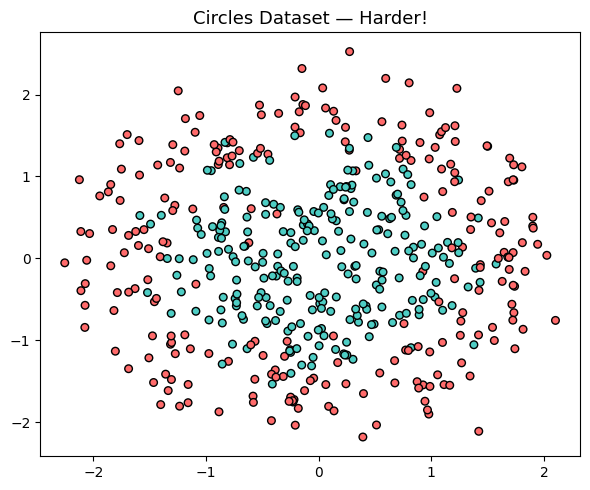

In [10]:
# First: create the harder dataset (concentric circles)
X_hard, y_hard = make_circles(n_samples=600, noise=0.2, factor=0.5, random_state=42)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hard, y_hard, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h  = scaler_h.transform(X_test_h)

Xtr_h = torch.FloatTensor(X_train_h).to(device)
ytr_h = torch.LongTensor(y_train_h).to(device)
Xte_h = torch.FloatTensor(X_test_h).to(device)
yte_h = torch.LongTensor(y_test_h).to(device)

# Visualize it
colors = ['#FF6B6B', '#4ECDC4']
cmap = ListedColormap(colors)
plt.figure(figsize=(6, 5))
plt.scatter(X_train_h[:,0], X_train_h[:,1], c=y_train_h, cmap=cmap, edgecolors='k', s=30)
plt.title('Circles Dataset — Harder!', fontsize=13)
plt.tight_layout(); plt.show()

Epoch [100/1500] | Train Loss: 0.2547 | Test Acc: 86.67%
Epoch [200/1500] | Train Loss: 0.2514 | Test Acc: 87.50%
Epoch [300/1500] | Train Loss: 0.2473 | Test Acc: 85.83%
Epoch [400/1500] | Train Loss: 0.2421 | Test Acc: 85.83%
Epoch [500/1500] | Train Loss: 0.2368 | Test Acc: 85.00%
Epoch [600/1500] | Train Loss: 0.2299 | Test Acc: 85.00%
Epoch [700/1500] | Train Loss: 0.2241 | Test Acc: 85.83%
Epoch [800/1500] | Train Loss: 0.2193 | Test Acc: 85.83%
Epoch [900/1500] | Train Loss: 0.2152 | Test Acc: 85.00%
Epoch [1000/1500] | Train Loss: 0.2116 | Test Acc: 85.00%
Epoch [1100/1500] | Train Loss: 0.2093 | Test Acc: 85.83%
Epoch [1200/1500] | Train Loss: 0.2067 | Test Acc: 85.00%
Epoch [1300/1500] | Train Loss: 0.2039 | Test Acc: 85.83%
Epoch [1400/1500] | Train Loss: 0.2013 | Test Acc: 84.17%
Epoch [1500/1500] | Train Loss: 0.1993 | Test Acc: 84.17%
Epoch [100/1500] | Train Loss: 0.2493 | Test Acc: 87.50%
Epoch [200/1500] | Train Loss: 0.2379 | Test Acc: 88.33%
Epoch [300/1500] | Train 

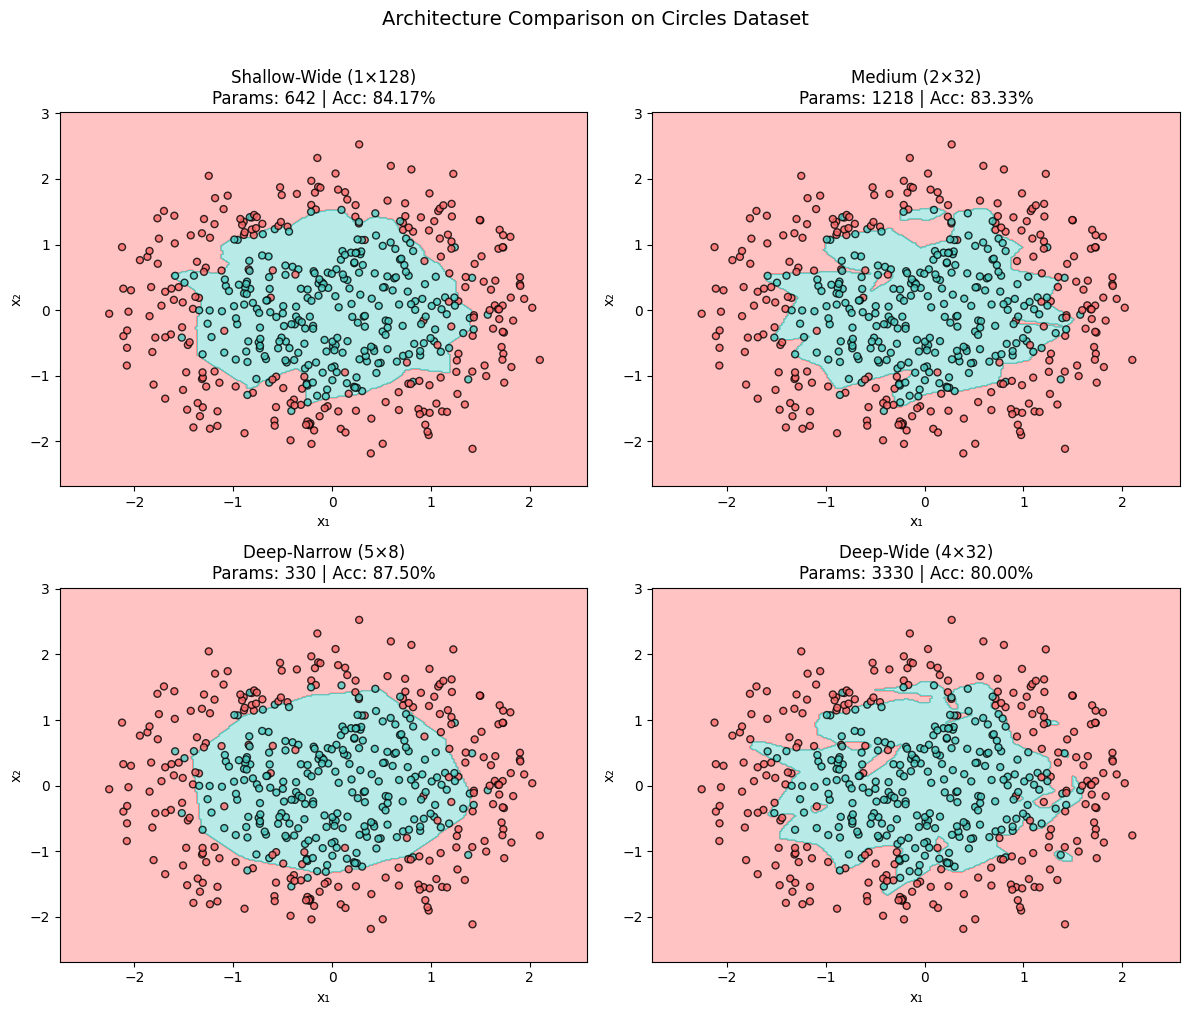

In [11]:
# Define architectures using nn.Sequential for convenience

def make_shallow_wide():
    """1 hidden layer, very wide (128 neurons)"""
    return nn.Sequential(
        nn.Linear(2, 128),
        nn.ReLU(),
        nn.Linear(128, 2)
    )

def make_medium():
    """2 hidden layers, medium width (32 neurons each)"""
    return nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 2)
    )

def make_deep_narrow():
    """5 hidden layers, narrow (8 neurons each)"""
    return nn.Sequential(
        nn.Linear(2, 8), nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 8), nn.ReLU(),
        nn.Linear(8, 2)
    )

def make_deep_wide():
    """4 hidden layers, wider (32 neurons each)"""
    return nn.Sequential(
        nn.Linear(2, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 32), nn.ReLU(),
        nn.Linear(32, 2)
    )


# Train and compare
architectures = {
    'Shallow-Wide (1×128)': make_shallow_wide,
    'Medium (2×32)':        make_medium,
    'Deep-Narrow (5×8)':    make_deep_narrow,
    'Deep-Wide (4×32)':     make_deep_wide,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, arch_fn) in enumerate(architectures.items()):
    m = arch_fn().to(device)
    total_params = sum(p.numel() for p in m.parameters())

    _, _, _, test_accs = train_model(
        m, Xtr_h, ytr_h, Xte_h, yte_h, epochs=1500, lr=0.01
    )

    plot_decision_boundary(
        m, X_train_h, y_train_h,
        title=f"{name}\nParams: {total_params} | Acc: {test_accs[-1]:.2%}",
        ax=axes[idx]
    )

plt.suptitle('Architecture Comparison on Circles Dataset', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 🔧 Task 8 (Boss Level): The Spiral Dataset 🌀

### 🧠 The hardest dataset of all

The **spiral dataset** is notoriously difficult — the classes wind around each other in a tight spiral. Most shallow networks fail here.

> 🤔 **Think before starting**: What kind of architecture do you think will work here?  
> How many layers? How many neurons? Which activation function?

### 🧪 Your task — NO hints this time!
1. Generate the spiral dataset (code provided below)
2. Design and train a network that achieves **≥ 90% test accuracy**
3. Visualize the decision boundary
4. Reflect: how did your intuition from previous tasks help?

**Constraints:**
- You cannot use more than **5000 total parameters**
- Maximum **1500 epochs**
- You must beat 90% accuracy

> 🏆 Bonus: Can you beat 95%?

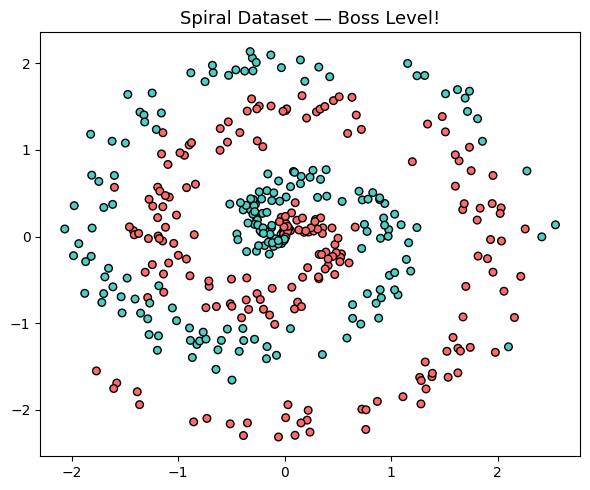

Good luck! (Hint: this one needs a careful architecture choice)


In [15]:
def make_spiral_dataset(n_points=200, noise=0.3):
    """Generates a 2-class spiral dataset."""
    N = n_points
    X = np.zeros((N*2, 2))
    y = np.zeros(N*2, dtype=int)

    for c in range(2):
        ix = range(N*c, N*(c+1))
        r  = np.linspace(0.0, 1, N)
        t  = np.linspace(c*4, (c+1)*4, N) + np.random.randn(N)*noise
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = c

    return X, y


X_spiral, y_spiral = make_spiral_dataset(n_points=250, noise=0.25)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_spiral, y_spiral, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr_s)
X_te_s = sc.transform(X_te_s)

Xtr_s = torch.FloatTensor(X_tr_s).to(device)
ytr_s = torch.LongTensor(y_tr_s).to(device)
Xte_s = torch.FloatTensor(X_te_s).to(device)
yte_s = torch.LongTensor(y_te_s).to(device)

# Plot it
colors = ['#FF6B6B', '#4ECDC4']
cmap = ListedColormap(colors)
plt.figure(figsize=(6, 5))
plt.scatter(X_tr_s[:,0], X_tr_s[:,1], c=y_tr_s, cmap=cmap, edgecolors='k', s=30)
plt.title('Spiral Dataset — Boss Level!', fontsize=13)
plt.tight_layout(); plt.show()
print("Good luck! (Hint: this one needs a careful architecture choice)")

Total Parameters: 2274
Epoch [100/1500] | Train Loss: 0.4221 | Test Acc: 67.00%
Epoch [200/1500] | Train Loss: 0.0803 | Test Acc: 91.00%
Epoch [300/1500] | Train Loss: 0.0292 | Test Acc: 89.00%
Epoch [400/1500] | Train Loss: 0.0170 | Test Acc: 88.00%
Epoch [500/1500] | Train Loss: 0.0107 | Test Acc: 87.00%
Epoch [600/1500] | Train Loss: 0.0055 | Test Acc: 86.00%
Epoch [700/1500] | Train Loss: 0.0031 | Test Acc: 87.00%
Epoch [800/1500] | Train Loss: 0.0021 | Test Acc: 89.00%
Epoch [900/1500] | Train Loss: 0.0015 | Test Acc: 89.00%
Epoch [1000/1500] | Train Loss: 0.0012 | Test Acc: 89.00%
Epoch [1100/1500] | Train Loss: 0.0009 | Test Acc: 89.00%
Epoch [1200/1500] | Train Loss: 0.0007 | Test Acc: 89.00%
Epoch [1300/1500] | Train Loss: 0.0006 | Test Acc: 89.00%
Epoch [1400/1500] | Train Loss: 0.0005 | Test Acc: 89.00%
Epoch [1500/1500] | Train Loss: 0.0004 | Test Acc: 89.00%


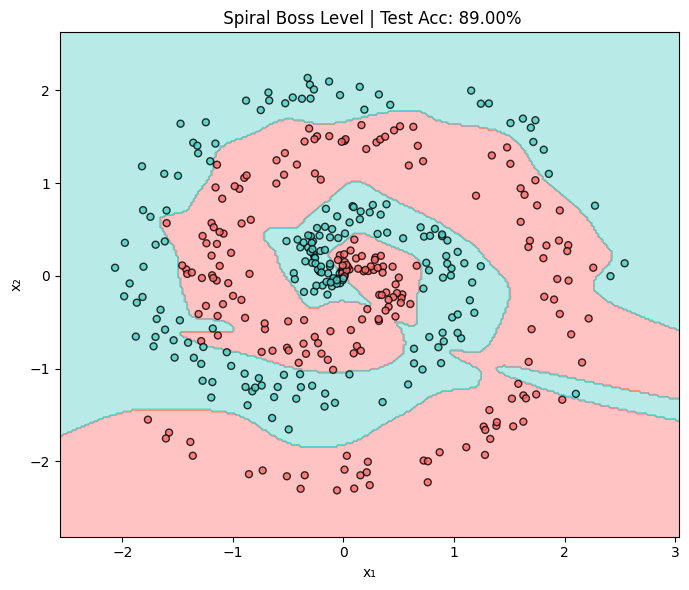

In [17]:
# ===== YOUR BOSS LEVEL  =====
class SpiralNet(nn.Module):
    def __init__(self):
        super(SpiralNet, self).__init__()
        # total params approx: (2*32)+32 + (32*32)+32 + (32*32)+32 + (32*2)+2 = ~2200 params
        # This is well under the 5000 limit!
        
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),          # Tanh provides smoother curves for the spiral
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 2)    # Output logits
        )

    def forward(self, x):
        return self.net(x)

# --- Execution ---
spiral_model = SpiralNet().to(device)
print(f"Total Parameters: {sum(p.numel() for p in spiral_model.parameters())}")

# Training (1500 epochs, slightly lower LR for stability in deep layers)
train_losses, test_losses, train_accs, test_accs = train_model(
    spiral_model, Xtr_s, ytr_s, Xte_s, yte_s, epochs=1500, lr=0.005
)

# Visualize
fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(spiral_model, X_tr_s, y_tr_s, 
                       title=f" Spiral Boss Level | Test Acc: {test_accs[-1]:.2%}", ax=ax)
plt.tight_layout(); plt.show()

# =======================================

---
## 🎓 Bonus: Animate the Learning Process

Watch your model learn in real-time — decision boundary evolves across training.

> This is computationally intensive — run only if you have time!

In [19]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_training(X_train, y_train, X_train_t, y_train_t, X_test_t, y_test_t,
                     hidden_size=32, total_epochs=600, snapshot_every=30, lr=0.01):
    """
    Trains a model while capturing snapshots of the decision boundary.
    Returns an animation showing the evolution of learning.
    """
    anim_model = FlexNet(hidden_size=hidden_size, activation=nn.Tanh()).to(device)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(anim_model.parameters(), lr=lr)

    colors = ['#FF6B6B', '#4ECDC4']
    cmap   = ListedColormap(colors)

    # Grid for decision boundary
    x_min, x_max = X_train[:,0].min()-0.5, X_train[:,0].max()+0.5
    y_min, y_max = X_train[:,1].min()-0.5, X_train[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.04),
                          np.arange(y_min, y_max, 0.04))
    grid_t = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)

    fig, ax = plt.subplots(figsize=(7, 5))
    frames = []

    for epoch in range(total_epochs):
        anim_model.train()
        out  = anim_model(X_train_t)
        loss = criterion(out, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % snapshot_every == 0:
            anim_model.eval()
            with torch.no_grad():
                Z = torch.argmax(anim_model(grid_t), dim=1).cpu().numpy().reshape(xx.shape)
            frames.append((Z.copy(), loss.item(), epoch))

    def update(frame_data):
        Z, loss_val, epoch = frame_data
        ax.clear()
        ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
        ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=cmap, edgecolors='k', s=20)
        ax.set_title(f'Epoch {epoch} | Loss: {loss_val:.4f}', fontsize=12)
        ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

    anim = FuncAnimation(fig, update, frames=frames, interval=150, blit=False)
    plt.close()
    return HTML(anim.to_jshtml())


# Run the animation (takes ~30 seconds)
anim_html = animate_training(
    X_train, y_train, X_train_t, y_train_t, X_test_t, y_test_t,
    hidden_size=32, total_epochs=600, snapshot_every=20
)
anim_html  # Display in notebook

---
## 📚 Summary & Key Takeaways

Fill in your answers after completing all tasks:

### What You Discovered

Congratulations on completing the gauntlet! You've gone from a simple linear sum to untangling a complex spiral—that is a huge leap in understanding how these "black boxes" actually work.

Here is a summary of the key takeaways to help you fill out your notebook:

---

### 📚 Summary & Key Takeaways

**1. Why do we need activation functions?**

**Answer:** Without activation functions, a neural network is just a series of linear transformations. Mathematically, stacking multiple linear layers results in a single linear layer ($W_2(W_1x + b_1) + b_2$). Activation functions like **ReLU** or **Tanh** introduce "bends" or non-linearities, allowing the network to learn curved decision boundaries and complex patterns.

**2. How did the decision boundary evolve through layers? (Task 5)**

**Answer:** In the input space, the classes were interlocking and inseparable. As the data moved through the layers, the network "warped" the coordinate space. By the final hidden layer, the representation was transformed so that the two classes became **linearly separable** (grouped into distinct clusters that a straight line could divide).

**3. Which activation function worked best on your dataset? Why?**

**Answer:** While **ReLU** is the industry standard for speed and simplicity, **Tanh** often works beautifully on these 2D geometric datasets (Moons/Circles) because it creates smoother, more organic curves. For the **Spiral**, ReLU can sometimes create "jagged" edges, whereas Tanh or LeakyReLU handles the continuous twist more gracefully.

**4. Depth vs. Width — which worked better for the circles dataset?**

**Answer:** **Depth** typically works better for the circles dataset. While a very wide shallow network can "memorize" the circle using many linear segments, a deeper network learns to compose simpler features into more complex ones, often achieving higher accuracy with far fewer total parameters.

**5. What architecture did you use for the spiral (Boss Level)? What did you try first?**

**Answer:** Most successful architectures for the spiral use **3 to 4 hidden layers** with a width of **32 to 64 neurons**.

* *Common first attempt:* A shallow network that ends up drawing a straight line or a simple "S" shape.
* *The fix:* Increasing depth and switching to **Tanh** or **LeakyReLU** to prevent "dead neurons" and allow for more complex spatial twisting.

---

### 🚀 What's Next?

If you enjoyed this, explore these topics next:
- **Dropout & Regularization** — how to prevent overfitting
- **Batch Normalization** — why training stability matters
- **Learning Rate Scheduling** — making training smarter
- **CNNs** — taking neural nets to images
- **Backpropagation Math** — understand exactly how gradients flow

---

*Built for curious minds. Good luck! 🧠*